# Лабораторна робота: Альтернативний аналіз та візуалізація даних
У цій роботі ми проведемо розвідувальний аналіз даних (EDA) світових соціально-економічних показників за 2007 рік.
Ми будемо використовувати нестандартні види графіків: фонову картограму (хороплет), пухирцеву діаграму, скрипковий графік та теплову карту кореляцій.

In [ ]:
# Імпорт необхідних бібліотек
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

# Завантаження вбудованого датасету Gapminder
df_all = px.data.gapminder()

# Відфільтровую дані лише за 2007 рік для актуального зрізу
df = df_all.query("year == 2007")

# Виведжу 5 перших рядків для перевірки
df.head()

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
11,Afghanistan,Asia,2007,43.828,31889923,974.580338,AFG,4
23,Albania,Europe,2007,76.423,3600523,5937.029526,ALB,8
35,Algeria,Africa,2007,72.301,33333216,6223.367465,DZA,12
47,Angola,Africa,2007,42.731,12420476,4797.231267,AGO,24
59,Argentina,Americas,2007,75.320,40301927,12779.379640,ARG,32


## 1. Геопросторовий аналіз (Choropleth Map)
Подивимося, як розподілена очікувана тривалість життя по країнах світу за допомогою інтерактивної карти.

In [ ]:
# Побудова інтерактивної карти
fig_map = px.choropleth(
    df,
    locations="iso_alpha",
    color="lifeExp",
    hover_name="country",
    color_continuous_scale=px.colors.sequential.Plasma,
    title="Очікувана тривалість життя у світі (2007 рік)"
)
fig_map.show()

## 2. Багатовимірний аналіз (Пухирцева діаграма)
Порівняємо відразу 4 параметри на одному графіку: ВВП на душу населення (вісь X), тривалість життя (вісь Y), населення (розмір пухирця) та континент (колір).

In [ ]:
# Побудова пухирцевої діаграми
fig_bubble = px.scatter(
    df,
    x="gdpPercap",
    y="lifeExp",
    size="pop",
    color="continent",
    hover_name="country",
    log_x=True, # Логарифмічна шкала для ВВП, оскільки розкид дуже великий
    size_max=60,
    title="ВВП на душу населення vs Тривалість життя"
)
fig_bubble.show()

## 3. Аналіз розподілу (Скрипковий графік / Violin Plot)
Подивимося на щільність розподілу та медіанні значення тривалості життя за континентами. На відміну від графіка "ящик з вусами" (boxplot), цей графік показує ще й ширину розподілу.

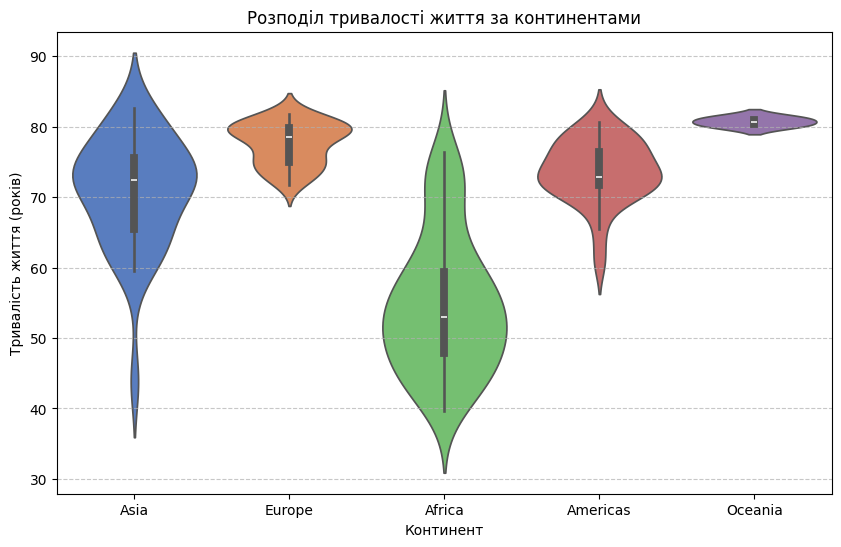

In [ ]:
plt.figure(figsize=(10, 6))
# Будую скрипковий графік
sns.violinplot(data=df, x="continent", y="lifeExp", palette="muted", hue="continent", legend=False)
plt.title("Розподіл тривалості життя за континентами")
plt.xlabel("Континент")
plt.ylabel("Тривалість життя (років)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 4. Кореляційний аналіз (Теплова карта / Heatmap)
Побудуємо матрицю кореляцій, щоб побачити математичну залежність між числовими змінними (ВВП, населення, тривалість життя).

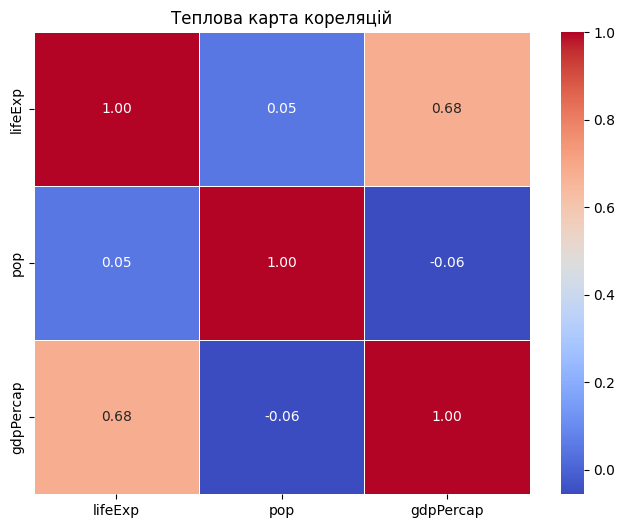

In [ ]:
plt.figure(figsize=(8, 6))
# Залишаю лише числові стовпці для кореляції
numeric_cols = df[['lifeExp', 'pop', 'gdpPercap']]
corr_matrix = numeric_cols.corr()

# Будую теплову карту
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Теплова карта кореляцій")
plt.show()